# ***1. Inversion de Colores (Negativo)***

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

In [ ]:
@cuda.jit
def invert_kernel_2D(img_color, img_inverted):
    j, i = cuda.grid(2)

    rows = img_inverted.shape[0]
    cols = img_inverted.shape[1]

    if i < rows and j < cols:
        img_inverted[i, j, 0] = 1.0 - img_color[i, j, 0]
        img_inverted[i, j, 1] = 1.0 - img_color[i, j, 1]
        img_inverted[i, j, 2] = 1.0 - img_color[i, j, 2]

In [ ]:
def image_to_inverted(img):
    ROWS, COLUMNS, COLOR = img.shape

    d_img_color = cuda.to_device(img)
    d_img_inverted = cuda.device_array((ROWS, COLUMNS, COLOR), dtype=np.float32)

    threadsperblock = (16, 16)
    blockspergrid_x = (COLUMNS + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (ROWS + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    invert_kernel_2D[blockspergrid, threadsperblock](d_img_color, d_img_inverted)

    return d_img_inverted.copy_to_host()

Saving images.jpg to images.jpg
Imagen cargada. Forma (H, W, C): 246x204x3


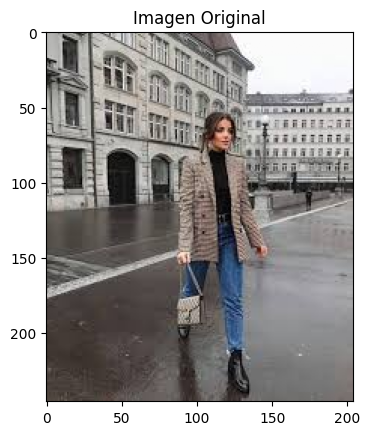

In [ ]:
uploaded = files.upload()

img_name = list(uploaded.keys())[0]
img_color = cv2.imread(img_name)
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_color_np = img_color_rgb.astype(np.float32) / 255.0

H, W, C = img_color_np.shape
print(f"Imagen cargada. Forma (H, W, C): {H}x{W}x{C}")

plt.imshow(img_color_np)
plt.title("Imagen Original")
plt.show()

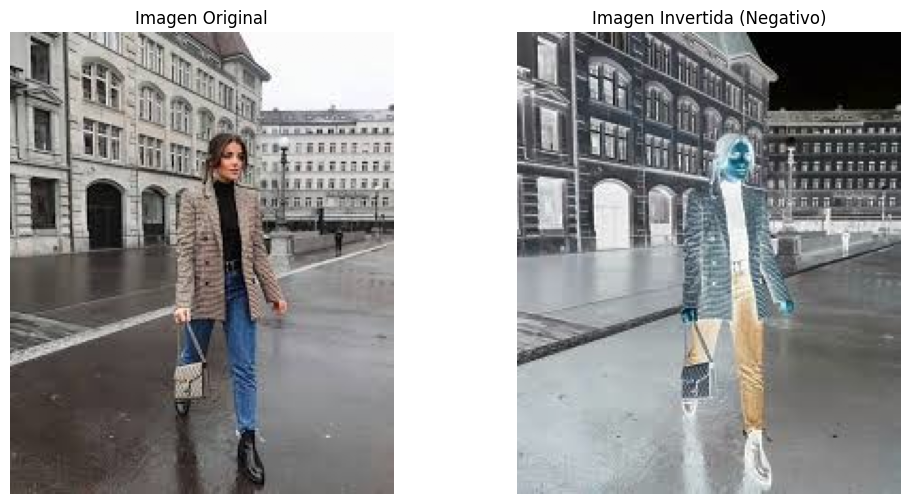

In [ ]:
img_inverted = image_to_inverted(img_color_np)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_color_np)
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_inverted)
plt.title("Imagen Invertida (Negativo)")
plt.axis('off')

plt.show()

# **2. Blur de una imagen**


In [9]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

In [10]:
@cuda.jit
def blur_kernel_2D(img_color, img_blurred, kernel_size):
    j, i = cuda.grid(2)

    rows = img_color.shape[0]
    cols = img_color.shape[1]

    if i < rows and j < cols:
        r = kernel_size // 2
        total_r = 0.0
        total_g = 0.0
        total_b = 0.0
        count = 0

        for di in range(-r, r + 1):
            for dj in range(-r, r + 1):
                ni = i + di
                nj = j + dj
                if ni >= 0 and ni < rows and nj >= 0 and nj < cols:
                    total_r += img_color[ni, nj, 0]
                    total_g += img_color[ni, nj, 1]
                    total_b += img_color[ni, nj, 2]
                    count += 1

        img_blurred[i, j, 0] = total_r / count
        img_blurred[i, j, 1] = total_g / count
        img_blurred[i, j, 2] = total_b / count

In [11]:
def image_to_blur(img, kernel_size):
    ROWS, COLUMNS, COLOR = img.shape

    d_img_color = cuda.to_device(img)
    d_img_blurred = cuda.device_array((ROWS, COLUMNS, COLOR), dtype=np.float32)

    threadsperblock = (16, 16)
    blockspergrid_x = (COLUMNS + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (ROWS + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    blur_kernel_2D[blockspergrid, threadsperblock](d_img_color, d_img_blurred, kernel_size)

    return d_img_blurred.copy_to_host()

Saving 678ea89fe388e.jpeg to 678ea89fe388e.jpeg
Imagen cargada. Forma (H, W, C): 475x950x3


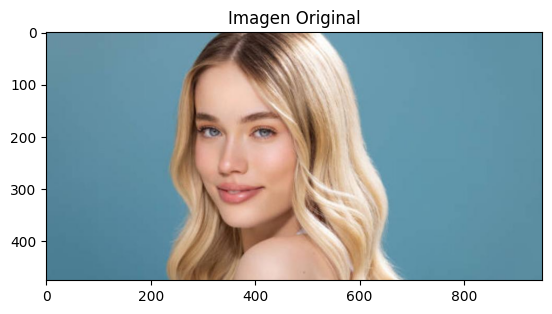

In [12]:
uploaded = files.upload()

img_name = list(uploaded.keys())[0]
img_color = cv2.imread(img_name)
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_color_np = img_color_rgb.astype(np.float32) / 255.0

H, W, C = img_color_np.shape
print(f"Imagen cargada. Forma (H, W, C): {H}x{W}x{C}")

plt.imshow(img_color_np)
plt.title("Imagen Original")
plt.show()

Ingresa el tamaño del kernel (ej: 3, 5, 7): 500


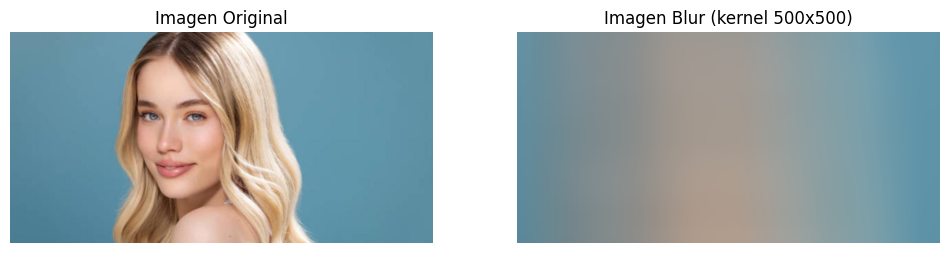

In [38]:
kernel_size = int(input("Ingresa el tamaño del kernel (ej: 3, 5, 7): "))

img_blurred = image_to_blur(img_color_np, kernel_size)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_color_np)
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_blurred)
plt.title(f"Imagen Blur (kernel {kernel_size}x{kernel_size})")
plt.axis('off')

plt.show()

# **3.  Recorte de imagen**

In [17]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

In [18]:
@cuda.jit
def crop_kernel_2D(img_color, img_cropped, x_start, y_start):
    j, i = cuda.grid(2)

    rows = img_cropped.shape[0]
    cols = img_cropped.shape[1]

    if i < rows and j < cols:
        src_i = i + y_start
        src_j = j + x_start

        img_cropped[i, j, 0] = img_color[src_i, src_j, 0]
        img_cropped[i, j, 1] = img_color[src_i, src_j, 1]
        img_cropped[i, j, 2] = img_color[src_i, src_j, 2]

In [19]:
def image_to_crop(img, x_start, y_start, width_crop, height_crop):
    ROWS, COLUMNS, COLOR = img.shape

    x_start = max(0, min(x_start, COLUMNS - 1))
    y_start = max(0, min(y_start, ROWS - 1))
    width_crop = min(width_crop, COLUMNS - x_start)
    height_crop = min(height_crop, ROWS - y_start)

    d_img_color = cuda.to_device(img)
    d_img_cropped = cuda.device_array((height_crop, width_crop, COLOR), dtype=np.float32)

    threadsperblock = (16, 16)
    blockspergrid_x = (width_crop + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (height_crop + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    crop_kernel_2D[blockspergrid, threadsperblock](d_img_color, d_img_cropped, x_start, y_start)

    return d_img_cropped.copy_to_host()

Saving 678ea89fe388e.jpeg to 678ea89fe388e (1).jpeg
Imagen cargada. Forma (H, W, C): 475x950x3


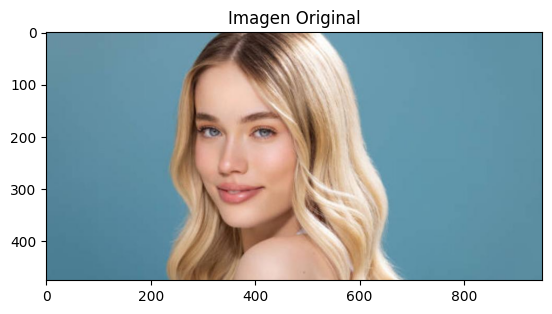

In [20]:
uploaded = files.upload()

img_name = list(uploaded.keys())[0]
img_color = cv2.imread(img_name)
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_color_np = img_color_rgb.astype(np.float32) / 255.0

H, W, C = img_color_np.shape
print(f"Imagen cargada. Forma (H, W, C): {H}x{W}x{C}")

plt.imshow(img_color_np)
plt.title("Imagen Original")
plt.show()

Dimensiones de la imagen: 950x475 (ancho x alto)
x_start: 25
y_start: 25
width_crop: 50
height_crop: 50


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


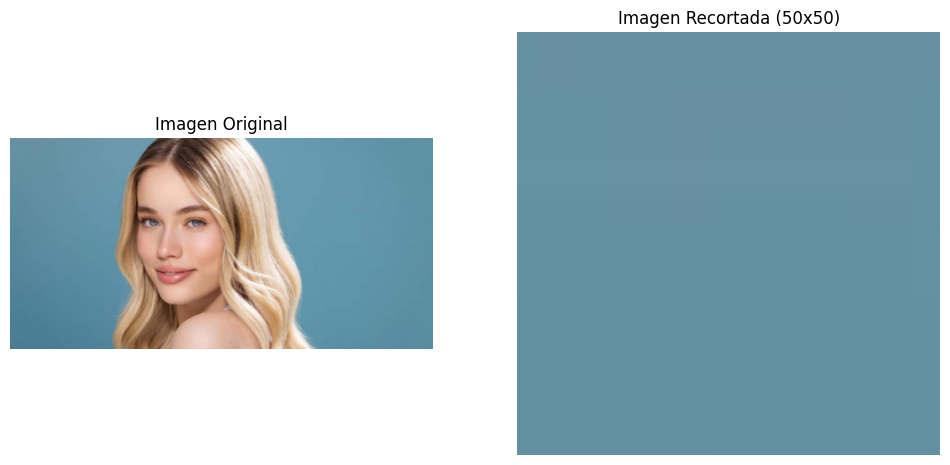

In [21]:
ROWS, COLUMNS, COLOR = img_color_np.shape
print(f"Dimensiones de la imagen: {COLUMNS}x{ROWS} (ancho x alto)")

x_start = int(input("x_start: "))
y_start = int(input("y_start: "))
width_crop = int(input("width_crop: "))
height_crop = int(input("height_crop: "))

img_cropped = image_to_crop(img_color_np, x_start, y_start, width_crop, height_crop)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_color_np)
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_cropped)
plt.title(f"Imagen Recortada ({width_crop}x{height_crop})")
plt.axis('off')

plt.show()

# **4.  Imagen binaria (blanco y negro)**

In [22]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

In [23]:
@cuda.jit
def binary_kernel_2D(img_color, img_binary, threshold):
    j, i = cuda.grid(2)

    rows = img_binary.shape[0]
    cols = img_binary.shape[1]

    if i < rows and j < cols:
        R = img_color[i, j, 0]
        G = img_color[i, j, 1]
        B = img_color[i, j, 2]

        intensity = (R + G + B) / 3.0

        if intensity > threshold:
            img_binary[i, j] = 1.0
        else:
            img_binary[i, j] = 0.0

In [24]:
def image_to_binary(img, threshold):
    ROWS, COLUMNS, COLOR = img.shape

    threshold_normalized = threshold / 255.0

    d_img_color = cuda.to_device(img)
    d_img_binary = cuda.device_array((ROWS, COLUMNS), dtype=np.float32)

    threadsperblock = (16, 16)
    blockspergrid_x = (COLUMNS + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (ROWS + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    binary_kernel_2D[blockspergrid, threadsperblock](d_img_color, d_img_binary, threshold_normalized)

    return d_img_binary.copy_to_host()

Saving 678ea89fe388e.jpeg to 678ea89fe388e (2).jpeg
Imagen cargada. Forma (H, W, C): 475x950x3


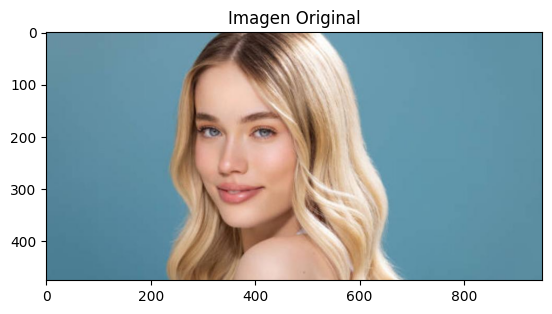

In [25]:
uploaded = files.upload()

img_name = list(uploaded.keys())[0]
img_color = cv2.imread(img_name)
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_color_np = img_color_rgb.astype(np.float32) / 255.0

H, W, C = img_color_np.shape
print(f"Imagen cargada. Forma (H, W, C): {H}x{W}x{C}")

plt.imshow(img_color_np)
plt.title("Imagen Original")
plt.show()

Ejemplos de umbral:
  T=64  -> imagen mayormente blanca
  T=128 -> equilibrio (valor típico)
  T=192 -> imagen mayormente negra
Ingresa el umbral T (0-255): 192


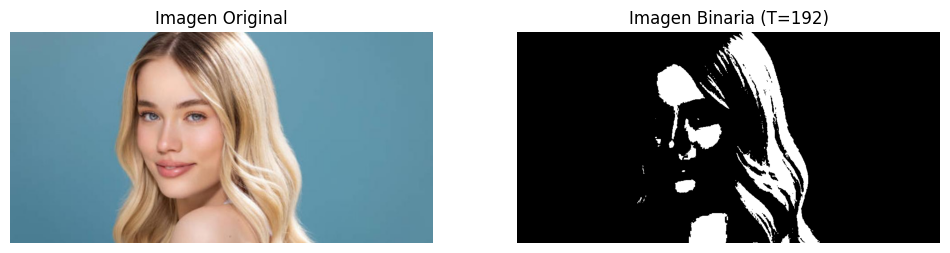

In [28]:
print("Ejemplos de umbral:")
print("  T=64  -> imagen mayormente blanca")
print("  T=128 -> equilibrio (valor típico)")
print("  T=192 -> imagen mayormente negra")

threshold = int(input("Ingresa el umbral T (0-255): "))

img_binary = image_to_binary(img_color_np, threshold)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_color_np)
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_binary, cmap='gray')
plt.title(f"Imagen Binaria (T={threshold})")
plt.axis('off')

plt.show()

# **5. . Detección de Bordes mediante algoritmo Sobel**

In [29]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

In [30]:
@cuda.jit
def grayscale_for_sobel_kernel(img_color, img_gray):
    j, i = cuda.grid(2)

    rows = img_gray.shape[0]
    cols = img_gray.shape[1]

    if i < rows and j < cols:
        R = img_color[i, j, 0]
        G = img_color[i, j, 1]
        B = img_color[i, j, 2]

        img_gray[i, j] = 0.2989 * R + 0.5870 * G + 0.1140 * B

In [31]:
@cuda.jit
def sobel_kernel_2D(img_gray, img_edges):
    j, i = cuda.grid(2)

    rows = img_gray.shape[0]
    cols = img_gray.shape[1]

    if i > 0 and i < rows - 1 and j > 0 and j < cols - 1:
        Gx = (img_gray[i-1, j+1] + 2.0 * img_gray[i, j+1] + img_gray[i+1, j+1]) - \
             (img_gray[i-1, j-1] + 2.0 * img_gray[i, j-1] + img_gray[i+1, j-1])

        Gy = (img_gray[i+1, j-1] + 2.0 * img_gray[i+1, j] + img_gray[i+1, j+1]) - \
             (img_gray[i-1, j-1] + 2.0 * img_gray[i-1, j] + img_gray[i-1, j+1])

        G = cuda.libdevice.sqrtf(Gx * Gx + Gy * Gy)

        if G > 1.0:
            G = 1.0

        img_edges[i, j] = G

In [32]:
def image_to_edges(img):
    ROWS, COLUMNS, COLOR = img.shape

    d_img_color = cuda.to_device(img)
    d_img_gray = cuda.device_array((ROWS, COLUMNS), dtype=np.float32)
    d_img_edges = cuda.device_array((ROWS, COLUMNS), dtype=np.float32)

    threadsperblock = (16, 16)
    blockspergrid_x = (COLUMNS + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (ROWS + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    grayscale_for_sobel_kernel[blockspergrid, threadsperblock](d_img_color, d_img_gray)
    cuda.synchronize()
    sobel_kernel_2D[blockspergrid, threadsperblock](d_img_gray, d_img_edges)

    return d_img_edges.copy_to_host()

Saving 678ea89fe388e.jpeg to 678ea89fe388e (3).jpeg
Imagen cargada. Forma (H, W, C): 475x950x3


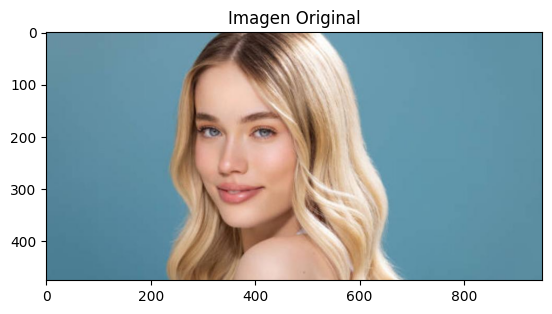

In [33]:
uploaded = files.upload()

img_name = list(uploaded.keys())[0]
img_color = cv2.imread(img_name)
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_color_np = img_color_rgb.astype(np.float32) / 255.0

H, W, C = img_color_np.shape
print(f"Imagen cargada. Forma (H, W, C): {H}x{W}x{C}")

plt.imshow(img_color_np)
plt.title("Imagen Original")
plt.show()

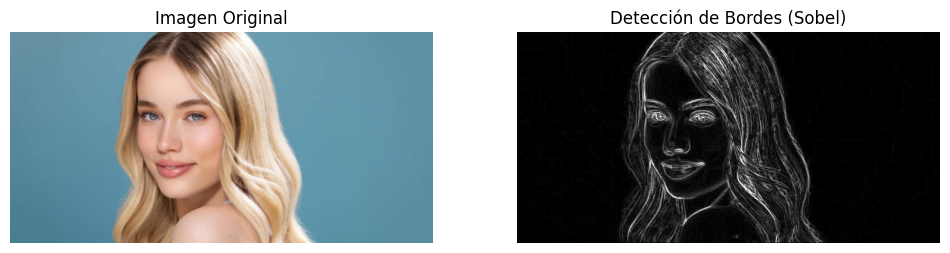

In [34]:
img_edges = image_to_edges(img_color_np)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_color_np)
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_edges, cmap='gray')
plt.title("Detección de Bordes (Sobel)")
plt.axis('off')

plt.show()